# Problem Statement (TODO)

### Importing Packages

In [ ]:
import pandas as pd

### Loading the csv files

In [ ]:
df_transactions = pd.read_csv('/content/df_transactions.csv')
df_kyc = pd.read_csv('/content/df_kyc.csv')
df_labels = pd.read_csv('/content/df_label.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/df_transactions.csv'

In [ ]:
df_transactions.columns

In [ ]:
df_labels.columns

In [ ]:
print("Transaction Dataframe shape" + str(df_transactions.shape))
print("KYC Dataframe shape" + str(df_kyc.shape))
print("Label Dataframe shape" + str(df_labels.shape))

### Merging the Data Frames

In [ ]:
df_transactions_labels = pd.merge(
    df_transactions,
    df_labels,
    on=["Customer_ID", "Month"],
    how="inner"
)

In [ ]:
df_transactions_labels.shape

In [ ]:
df_transactions_labels = pd.merge(
    df_transactions,
    df_labels,
    on=["Customer_ID", "Month"],
    how="outer"
)

In [ ]:
df_transactions_labels.shape

In [ ]:
df_transactions_labels.head()

In [ ]:
df_merged = pd.merge(
    df_transactions_labels,
    df_kyc,
    on="Customer_ID",
    how="inner"
)

In [ ]:
df_merged.shape

In [ ]:
df_merged.head()

In [ ]:
df_merged['Transaction_Type'].unique()

In [ ]:
df_salary = df_merged[df_merged['Transaction_Type'] == 'Salary']
df_salary.head()

In [ ]:
# Grouping by Customer ID and applying the condition on the SAR column
df_grouped = df_salary.groupby('Customer_ID').agg({
    'SAR': lambda x: 1 if (x == 1).any() else 0,  # Set SAR to 1 if any SAR value is 1, otherwise 0
    # Include other columns you want to aggregate, e.g., summing transactions:
    # 'Transaction_Amount': 'sum',
    # 'Other_Column': 'sum'
}).reset_index()

# Preview the grouped dataframe
df_grouped.head()

NameError: name 'df_salary' is not defined

In [ ]:
# Grouping by Customer_ID and aggregating both SAR and Transaction_Value
df_grouped = df_salary.groupby('Customer_ID').agg({
    'SAR': lambda x: 1 if (x == 1).any() else 0,  # Set SAR to 1 if any SAR value is 1, otherwise 0
    'Transaction_Value': 'mean',  # Summing the transaction values for each customer
}).reset_index()

# Preview the grouped dataframe
df_grouped.head()


,Customer_ID,SAR,Transaction_Value
0,1,1,3803.0
1,3,1,6293.0
2,4,0,8107.0
3,6,0,1151.0
4,7,0,4422.0


In [ ]:
# Calculate the correlation between SAR and Transaction_Value
correlation = df_grouped['SAR'].corr(df_grouped['Transaction_Value'])
print(f"Correlation between SAR and Transaction Value: {correlation}")

Correlation between SAR and Transaction Value: 0.5122999699463743


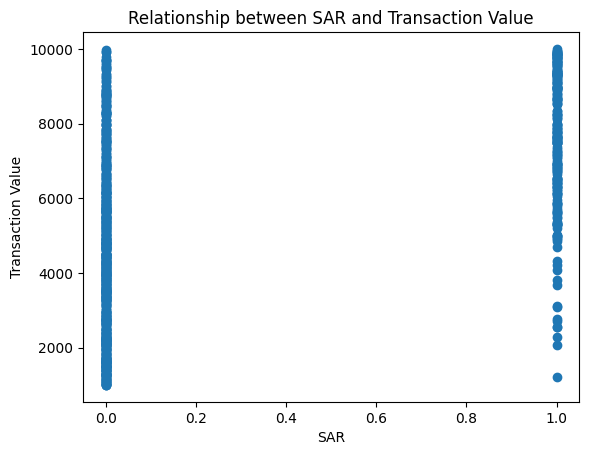

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot to visualize the relationship between SAR and Transaction_Value
plt.scatter(df_grouped['SAR'], df_grouped['Transaction_Value'])
plt.title('Relationship between SAR and Transaction Value')
plt.xlabel('SAR')
plt.ylabel('Transaction Value')
plt.show()

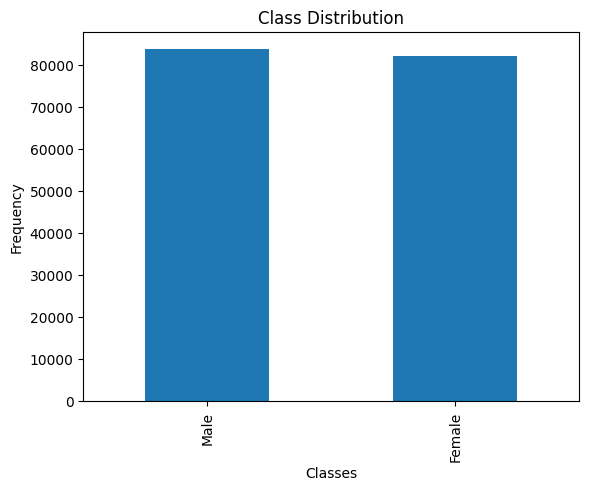

In [ ]:
import matplotlib.pyplot as plt

# Plot the class distribution
df_merged['Sex'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Frequency')
plt.show()


In [ ]:
import pandas as pd

# Assuming your DataFrame is named 'df' and the target column is 'target'
class_distribution = df_merged['High_Risk_Country'].value_counts()
print(class_distribution)


High_Risk_Country
False    130964
True      34770
Name: count, dtype: int64


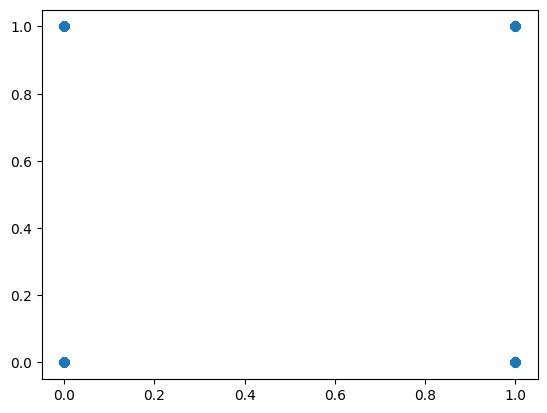

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=df_merged['SAR'], y=df_merged['Intention_Cash_Deposits'])
plt.show()

In [ ]:
df_merged.isnull().sum()

,0
Customer_ID,0
Customer_ID_Counterparty,151258
Transaction_Value,0
Transaction_Type,0
Month,0
SAR,0
Age,0
Sex,0
High_Risk_Country,0
Vulnerable_Area,0


In [ ]:
df_merged['Customer_ID_Counterparty'].unique()

array([ nan, 241., 127., ..., 996., 266., 477.])

In [ ]:
df_merged['Transaction_Type'].value_counts()

,count
Transaction_Type,
Wire,151285
Salary,9588
International,2448
Cash,2413


In [ ]:
df_merged['SAR'].value_counts()

,count
SAR,
0,158122
1,7612


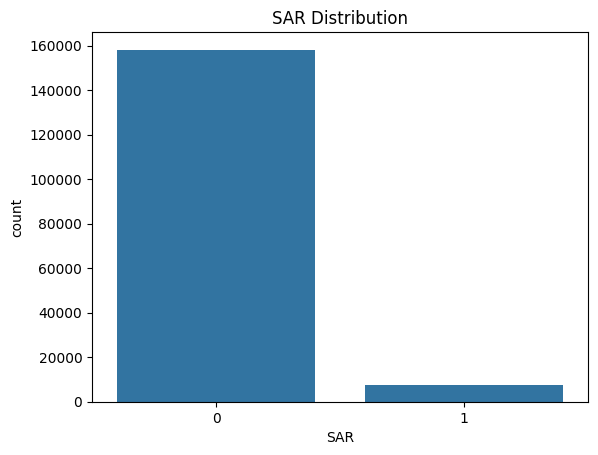

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='SAR', data=df_merged)
plt.title('SAR Distribut<ion')
plt.show()

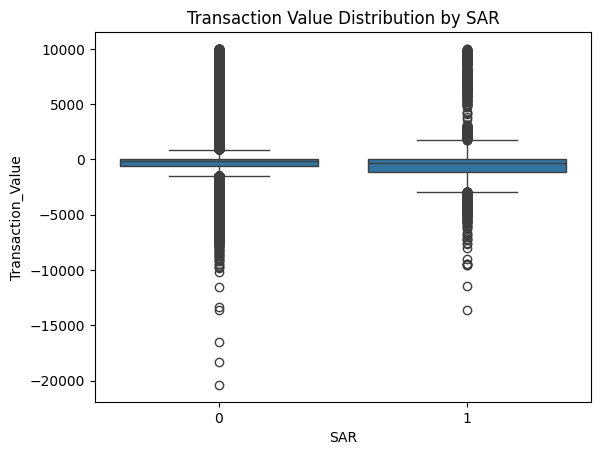

In [ ]:
sns.boxplot(data=df_merged, x='SAR', y='Transaction_Value')
plt.title('Transaction Value Distribution by SAR')
plt.show()

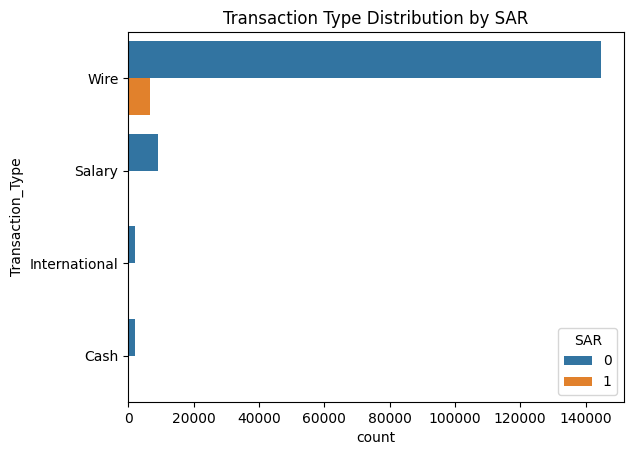

In [ ]:
sns.countplot(y='Transaction_Type', hue='SAR', data=df_merged)
plt.title('Transaction Type Distribution by SAR')
plt.show()


In [ ]:
correlation_matrix = df_merged.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


ValueError: could not convert string to float: 'Wire'

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165734 entries, 0 to 165733
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Customer_ID                       165734 non-null  int64  
 1   Customer_ID_Counterparty          14476 non-null   float64
 2   Transaction_Value                 165734 non-null  int64  
 3   Transaction_Type                  165734 non-null  object 
 4   Month                             165734 non-null  object 
 5   SAR                               165734 non-null  int64  
 6   Age                               165734 non-null  int64  
 7   Sex                               165734 non-null  object 
 8   High_Risk_Country                 165734 non-null  bool   
 9   Vulnerable_Area                   165734 non-null  bool   
 10  Intention_International_Payments  165734 non-null  bool   
 11  Intention_Cash_Deposits           165734 non-null  b

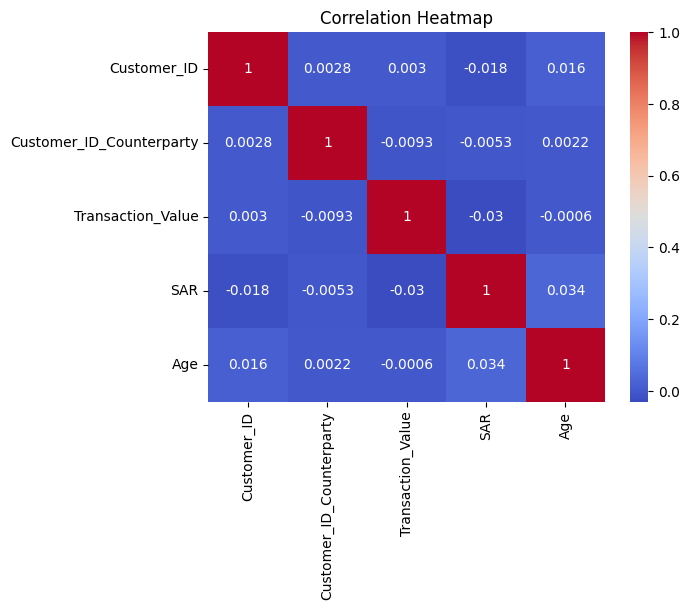

In [ ]:
numeric_df = df_merged.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df_transactions = pd.read_csv('/content/df_transactions.csv')
df_kyc = pd.read_csv('/content/df_kyc.csv')
df_labels = pd.read_csv('/content/df_label.csv')

In [ ]:
df_labels.head()

,Customer_ID,Month,SAR
0,1,Apr,0
1,1,Aug,1
2,1,Dec,0
3,1,Feb,0
4,1,Jan,0


In [ ]:
# prompt: for the above data frame, I want to merge all customer_id and where SAR is 1, it will be 1 for that customer_id

# Assuming df_labels is your DataFrame
df_labels_grouped = df_labels.groupby('Customer_ID')['SAR'].max().reset_index()
df_labels_grouped.rename(columns={'SAR': 'SAR_merged'}, inplace=True)

df_labels_grouped.head()
df_labels_grouped.shape

(1000, 2)

In [ ]:
df_merged = df_labels_grouped.merge(df_kyc, on='Customer_ID', how='inner')
df_merged.head()

,Customer_ID,SAR_merged,Age,Sex,High_Risk_Country,Vulnerable_Area,Intention_International_Payments,Intention_Cash_Deposits
0,1,1,28,Male,False,False,True,False
1,2,0,80,Male,False,False,False,False
2,3,1,79,Female,False,False,False,False
3,4,0,34,Female,False,False,False,False
4,5,1,58,Male,False,False,False,False


In [ ]:
# prompt: Using dataframe df_merged: where I can corelated Age and SAR_merged

# Calculate the correlation between 'Age' and 'SAR_merged'
correlation = df_merged['Age'].corr(df_merged['SAR_merged'])

# Print the correlation coefficient
print(f"The correlation between Age and SAR_merged is: {correlation}")

The correlation between Age and SAR_merged is: 0.06639076471300262


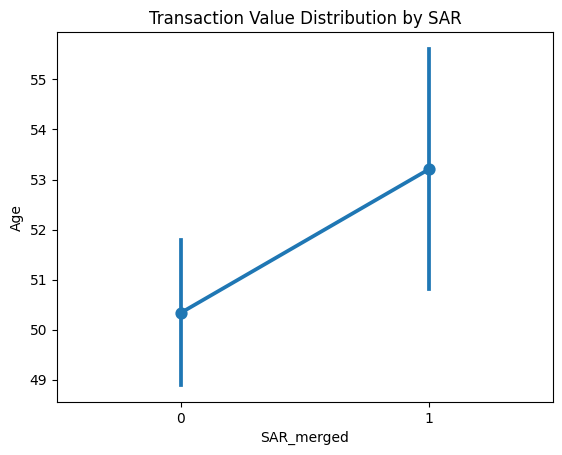

In [ ]:
# prompt: give me a box or a point plot

sns.pointplot(data=df_merged, x='SAR_merged', y='Age')
plt.title('Transaction Value Distribution by SAR')
plt.show()

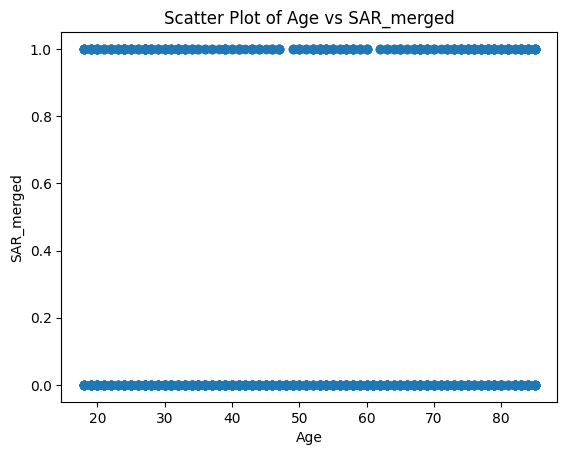

In [ ]:
# prompt: give a scatter plot for the above

plt.scatter(df_merged['Age'], df_merged['SAR_merged'])
plt.title('Scatter Plot of Age vs SAR_merged')
plt.xlabel('Age')
plt.ylabel('SAR_merged')
plt.show()

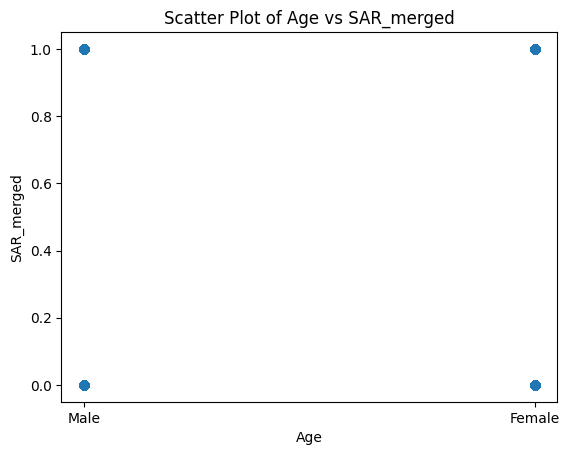

In [ ]:
plt.scatter(df_merged['Sex'], df_merged['SAR_merged'])
plt.title('Scatter Plot of Age vs SAR_merged')
plt.xlabel('Age')
plt.ylabel('SAR_merged')
plt.show()

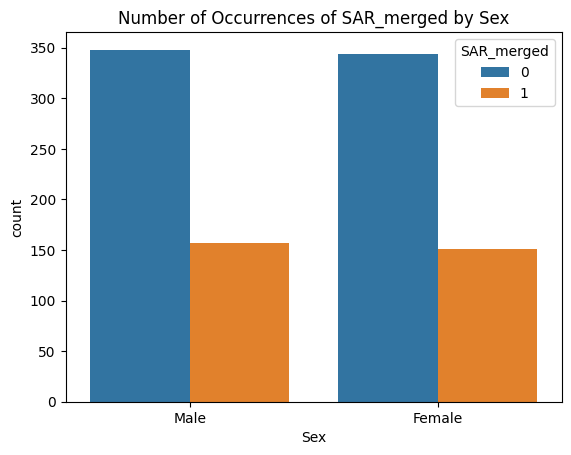

In [ ]:
# prompt: a plot which gives number of occurence between Sex and SAR_merged

sns.countplot(x='Sex', hue='SAR_merged', data=df_merged)
plt.title('Number of Occurrences of SAR_merged by Sex')
plt.show()

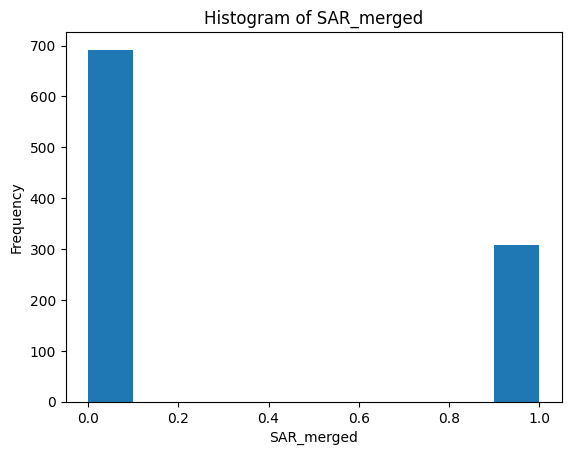

In [ ]:
# prompt: create a historgram for Sex and SAR_merged

plt.hist(df_merged['SAR_merged'], bins=10)  # Adjust bins as needed
plt.title('Histogram of SAR_merged')
plt.xlabel('SAR_merged')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print("Hello")